In [24]:
from pathlib import Path


import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import streamlit as st
from dotenv import load_dotenv
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


In [25]:
# Objetivo: cargar los datasets base de entrenamiento desde rutas relativas seguras.
# Explicacion tecnica: usamos Path para evitar errores de rutas y facilitar que el notebook funcione
# igual en distintos equipos o carpetas del proyecto.
# Explicacion negocio: aqui reunimos las dos fuentes que explican el problema,
# ventas historicas y precios de la competencia.
data_dir = Path("../data/raw/entrenamiento")
ventas_path = data_dir / "ventas.csv"
competencia_path = data_dir / "competencia.csv"

ventas_df = pd.read_csv(ventas_path)
competencia_df = pd.read_csv(competencia_path)

# Objetivo: comprobar rapidamente que la carga fue correcta.
print(f"ventas_df shape: {ventas_df.shape}")
print(f"competencia_df shape: {competencia_df.shape}")

# Mostramos una vista previa para validar estructura y contenido.
print("Ventas:")
display(ventas_df.head())
print("Competencia:")
display(competencia_df.head())


ventas_df shape: (3552, 10)
competencia_df shape: (3552, 5)
Ventas:


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


Competencia:


,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [26]:
ventas_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [27]:
competencia_df.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [28]:
ventas_df.columns   


Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='object')

In [29]:
competencia_df.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='object')

## Calidad de datos
En esta seccion validamos si los datasets son fiables para analisis y forecasting.
El objetivo es detectar problemas de estructura, integridad y consistencia antes de modelar.


In [30]:
# Objetivo: evaluar si ventas_df esta listo para analisis y modelado sin problemas de calidad.
# Explicacion negocio: este bloque nos ayuda a justificar si podemos confiar en el historico
# antes de tomar decisiones o entrenar un modelo.
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')

# Medidas generales de integridad del dataset.
n_registros, n_columnas = ventas_df.shape
n_duplicados = ventas_df.duplicated().sum()
nulos = ventas_df.isna().sum()
pct_nulos = (nulos / n_registros * 100).round(2)
min_fecha = ventas_df['fecha'].min()
max_fecha = ventas_df['fecha'].max()
n_fechas_unicas = ventas_df['fecha'].nunique()
tipos_datos_df = ventas_df.dtypes.astype(str).to_frame('tipo_dato')

# Tabla resumen para detectar columnas problematicas por tipo, nulos o cardinalidad.
informe_calidad_df = pd.DataFrame({
    'tipo_dato': ventas_df.dtypes.astype(str),
    'nulos': nulos,
    'pct_nulos': pct_nulos,
    'n_unicos': ventas_df.nunique()
}).sort_values(by=['pct_nulos', 'nulos'], ascending=False)

# Descriptivos numericos para entender dispersion, rangos y posibles outliers.
descriptivo_numerico_df = ventas_df.select_dtypes(include=['int64', 'float64']).describe().T

# Descriptivos categoricos para ver cardinalidad y valores mas frecuentes.
descriptivo_categorico_df = ventas_df.describe(include=['object', 'category', 'bool']).T

# Resumen temporal separado para no mezclar fechas con metricas numericas.
resumen_temporal_df = pd.DataFrame({
    'fecha_min': [min_fecha],
    'fecha_max': [max_fecha],
    'n_fechas_unicas': [n_fechas_unicas]
})

print('INFORME DE CALIDAD DE DATOS - ventas_df')
print('-' * 50)
print(f'Registros: {n_registros}')
print(f'Columnas: {n_columnas}')
print(f'Duplicados exactos: {n_duplicados}')

print('Resumen temporal:')
display(resumen_temporal_df)

print('Tipos de datos:')
display(tipos_datos_df)

print('Tipos de datos, nulos y cardinalidad:')
display(informe_calidad_df)

print('Descriptivos numericos:')
display(descriptivo_numerico_df)

print('Descriptivos categoricos y booleanos:')
display(descriptivo_categorico_df)

print('Nulos por columna:')
display(nulos.to_frame('nulos'))


INFORME DE CALIDAD DE DATOS - ventas_df
--------------------------------------------------
Registros: 3552
Columnas: 10
Duplicados exactos: 0
Resumen temporal:


,fecha_min,fecha_max,n_fechas_unicas
0,2021-10-25,2024-11-30,148


Tipos de datos:


,tipo_dato
fecha,datetime64[ns]
producto_id,object
nombre,object
categoria,object
subcategoria,object
precio_base,int64
es_estrella,bool
unidades_vendidas,int64
precio_venta,float64
ingresos,float64


Tipos de datos, nulos y cardinalidad:


...

,count,mean,std,min,25%,50%,75%,max
precio_base,3552.0,123.125000,165.576753,20.00,48.7500,72.50,118.7500,830.00
unidades_vendidas,3552.0,4.878660,6.311020,1.00,2.0000,3.00,5.0000,85.00
precio_venta,3552.0,121.816546,164.017963,19.00,47.2125,71.81,118.2200,854.22
ingresos,3552.0,605.972323,1079.071192,19.46,131.5350,216.57,639.6375,14508.40


Descriptivos categoricos y booleanos:


,count,unique,top,freq
producto_id,3552,24,PROD_001,148
nombre,3552,24,Nike Air Zoom Pegasus 40,148
categoria,3552,4,Running,1184
subcategoria,3552,16,Zapatillas Running,888
es_estrella,3552,2,False,2516


Nulos por columna:


,nulos
fecha,0
producto_id,0
nombre,0
categoria,0
subcategoria,0
precio_base,0
es_estrella,0
unidades_vendidas,0
precio_venta,0
ingresos,0


In [31]:
# Objetivo: validar la calidad del dataset de competencia antes de cruzarlo con ventas.
# Explicacion negocio: este bloque asegura que las referencias de mercado son consistentes
# y pueden incorporarse al modelo como contexto competitivo.
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')

n_registros, n_columnas = competencia_df.shape
n_duplicados = competencia_df.duplicated().sum()
nulos = competencia_df.isna().sum()
pct_nulos = (nulos / n_registros * 100).round(2)
min_fecha = competencia_df['fecha'].min()
max_fecha = competencia_df['fecha'].max()
n_fechas_unicas = competencia_df['fecha'].nunique()
tipos_datos_df = competencia_df.dtypes.astype(str).to_frame('tipo_dato')

informe_calidad_df = pd.DataFrame({
    'tipo_dato': competencia_df.dtypes.astype(str),
    'nulos': nulos,
    'pct_nulos': pct_nulos,
    'n_unicos': competencia_df.nunique()
}).sort_values(by=['pct_nulos', 'nulos'], ascending=False)

# Descriptivos de precios de competidores para entender nivel y variabilidad del mercado.
descriptivo_numerico_df = competencia_df.select_dtypes(include=['int64', 'float64']).describe().T
descriptivo_categorico_df = competencia_df.describe(include=['object']).T
resumen_temporal_df = pd.DataFrame({
    'fecha_min': [min_fecha],
    'fecha_max': [max_fecha],
    'n_fechas_unicas': [n_fechas_unicas]
})

print('INFORME DE CALIDAD DE DATOS - competencia_df')
print('-' * 50)
print(f'Registros: {n_registros}')
print(f'Columnas: {n_columnas}')
print(f'Duplicados exactos: {n_duplicados}')

print('Resumen temporal:')
display(resumen_temporal_df)

print('Tipos de datos:')
display(tipos_datos_df)

print('Tipos de datos, nulos y cardinalidad:')
display(informe_calidad_df)

print('Descriptivos numericos:')
display(descriptivo_numerico_df)

print('Descriptivos categoricos:')
display(descriptivo_categorico_df)

print('Nulos por columna:')
display(nulos.to_frame('nulos'))


INFORME DE CALIDAD DE DATOS - competencia_df
--------------------------------------------------
Registros: 3552
Columnas: 5
Duplicados exactos: 0
Resumen temporal:


,fecha_min,fecha_max,n_fechas_unicas
0,2021-10-25,2024-11-30,148


Tipos de datos:


,tipo_dato
fecha,datetime64[ns]
producto_id,object
Amazon,float64
Decathlon,float64
Deporvillage,float64


Tipos de datos, nulos y cardinalidad:


...

,count,mean,std,min,25%,50%,75%,max
Amazon,3552.0,118.623407,156.095628,16.85,47.1175,73.180,114.3425,858.3500
Decathlon,3552.0,111.412182,148.508132,15.45,43.2850,66.285,111.1725,867.3375
Deporvillage,3552.0,118.894628,160.216448,16.77,47.3100,72.700,114.9850,932.3250


Descriptivos categoricos:


,count,unique,top,freq
producto_id,3552,24,PROD_001,148


Nulos por columna:


,nulos
fecha,0
producto_id,0
Amazon,0
Decathlon,0
Deporvillage,0


## Analisis temporal
A partir de aqui miramos el comportamiento de ventas en el tiempo para explicar tendencia, ritmo y patrones recurrentes.


Tipos de fecha convertidos:
ventas_df[fecha]: datetime64[ns]
competencia_df[fecha]: datetime64[ns]
Resumen temporal de ventas_df:
Fechas unicas: 148
Primera fecha: 2021-10-25 00:00:00
Ultima fecha: 2024-11-30 00:00:00


,fecha,unidades_vendidas,ingresos
0,2021-10-25,61,7799.58
1,2021-10-26,62,7952.59
2,2021-10-27,60,7793.26
3,2021-10-28,58,7199.84
4,2021-10-29,70,8480.21


,anio,mes,unidades_vendidas,ingresos
0,2021,10,461,58878.89
1,2021,11,3305,399016.51
2,2022,10,520,69851.79
3,2022,11,3805,455486.27
4,2023,10,588,77236.57


,dia_semana,unidades_vendidas,ingresos
1,Monday,2321,282704.36
5,Tuesday,2164,273680.18
6,Wednesday,2068,263989.59
4,Thursday,1718,224837.41
0,Friday,3140,377659.86
2,Saturday,3405,421206.36
3,Sunday,2513,308335.93


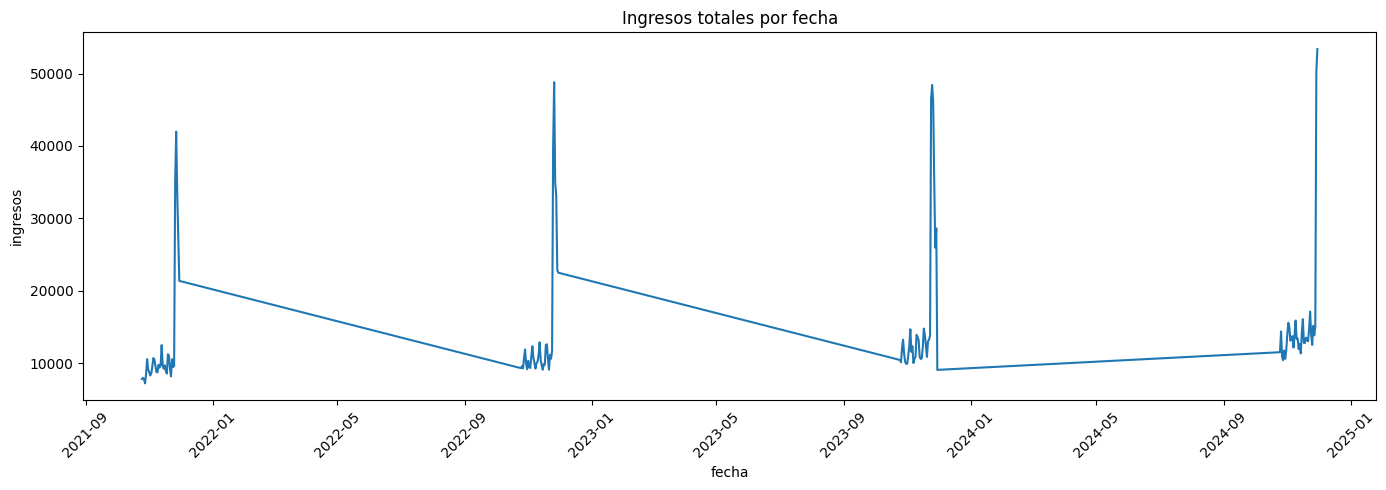

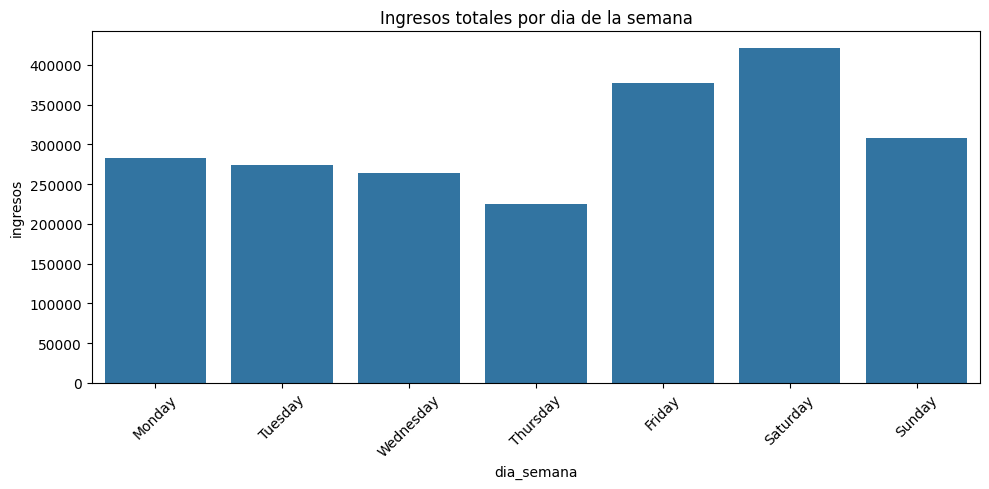

In [32]:
# Objetivo: preparar la variable fecha y construir una primera lectura temporal del negocio.
# Explicacion negocio: este bloque ayuda a responder cuando vendemos mas, como evoluciona
# la facturacion y si existe patron por dia de la semana o por mes.
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')

print('Tipos de fecha convertidos:')
print('ventas_df[fecha]:', ventas_df['fecha'].dtype)
print('competencia_df[fecha]:', competencia_df['fecha'].dtype)

# Creamos una copia para enriquecerla con variables temporales sin tocar el dataset base.
ventas_temporal_df = ventas_df.copy()
ventas_temporal_df['anio'] = ventas_temporal_df['fecha'].dt.year
ventas_temporal_df['mes'] = ventas_temporal_df['fecha'].dt.month
ventas_temporal_df['dia_semana'] = ventas_temporal_df['fecha'].dt.day_name()

# Agregados temporales para resumir comportamiento diario, mensual y semanal.
ventas_por_fecha_df = ventas_temporal_df.groupby('fecha', as_index=False)[['unidades_vendidas', 'ingresos']].sum()
ventas_por_mes_df = ventas_temporal_df.groupby(['anio', 'mes'], as_index=False)[['unidades_vendidas', 'ingresos']].sum()
ventas_por_dia_semana_df = ventas_temporal_df.groupby('dia_semana', as_index=False)[['unidades_vendidas', 'ingresos']].sum()

# Ordenamos los dias para que la lectura visual siga la secuencia natural de la semana.
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_por_dia_semana_df['dia_semana'] = pd.Categorical(ventas_por_dia_semana_df['dia_semana'], categories=orden_dias, ordered=True)
ventas_por_dia_semana_df = ventas_por_dia_semana_df.sort_values('dia_semana')

print('Resumen temporal de ventas_df:')
print('Fechas unicas:', ventas_temporal_df['fecha'].nunique())
print('Primera fecha:', ventas_temporal_df['fecha'].min())
print('Ultima fecha:', ventas_temporal_df['fecha'].max())

# Tablas de apoyo para explicar el analisis antes de las graficas.
display(ventas_por_fecha_df.head())
display(ventas_por_mes_df.head())
display(ventas_por_dia_semana_df)

# Grafica 1: evolucion temporal de ingresos.
# Utilidad para negocio: detectar tendencia, estacionalidad y posibles picos o caidas anormales.
plt.figure(figsize=(14, 5))
sns.lineplot(data=ventas_por_fecha_df, x='fecha', y='ingresos')
plt.title('Ingresos totales por fecha')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Grafica 2: ingresos acumulados por dia de la semana.
# Utilidad para negocio: identificar dias fuertes y dias flojos para promociones, stock o personal.
plt.figure(figsize=(10, 5))
sns.barplot(data=ventas_por_dia_semana_df, x='dia_semana', y='ingresos')
plt.title('Ingresos totales por dia de la semana')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Union de fuentes
En esta parte combinamos ventas y competencia para construir una base unica lista para analisis avanzado o modelado predictivo.


In [33]:
# Objetivo: construir una tabla analitica unica para modelado y analisis conjunto.
# Explicacion negocio: esta union permite estudiar ventas propias junto con el contexto de precios
# de la competencia para cada producto y fecha.

# Usamos un cruce inner para conservar solo registros presentes en ambas fuentes.
# Claves de union: fecha y producto_id.
df = ventas_df.merge(competencia_df, on=['fecha', 'producto_id'], how='inner')

# Validaciones basicas tras la union.
print('df shape:', df.shape)
print('Columnas de df:')
display(df.columns.to_frame(index=False))

# Vista previa de la tabla final para confirmar que la union fue correcta.
display(df.head())


df shape: (3552, 13)
Columnas de df:


,0
0,fecha
1,producto_id
2,nombre
3,categoria
4,subcategoria
5,precio_base
6,es_estrella
7,unidades_vendidas
8,precio_venta
9,ingresos


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07
